# 小節線のアノテーション

#### 方針
- segmentationのデータを利用する。
- segmentationのデータから小節線のピクセル座標を得られる。
- 得られた座標からバウンディングボックスを定義する。

#### 出力イメージ
一つの小節線検出につき一つのバウンディングボックスを得る。出力は以下のイメージ<br>
img_id x y width height<br>
679 1718.0 561.0 1748.0 564.0<br>

## 目次 
### 1. 画像読み込み
### 2. 小節線のピクセル位置を取得
### 3. バウンディングボックスを定義



In [24]:
from pathlib import Path
import cv2
import numpy as np
from scipy.spatial.distance import euclidean
import  cv2
from PIL import Image
from tqdm import tqdm
from scipy.spatial import KDTree
from matplotlib import pyplot as plt
%matplotlib inline

In [25]:
cv2.__version__

'4.10.0'

## 1. 画像の読み込み

In [26]:
data_dir = Path("../data/")
images_dir = data_dir / "ds2_dense/images/"
seg_dir = data_dir / "ds2_dense/segmentation/"
filename = "lg-2267728-aug-beethoven--page-2.png"
seg_filename = "lg-2267728-aug-beethoven--page-2_seg.png"

In [27]:
def show_img(img: np.ndarray):
    """画像を表示する"""
    print("画像のサイズ：　",img.shape)
    plt.figure(figsize=(20,20))
    plt.imshow(img,cmap = "gray")
    plt.xticks([])
    plt.yticks([])
    plt.show()


<class 'PIL.Image.Image'>
<class 'numpy.ndarray'>
画像のサイズ：　 (2772, 1960, 3)


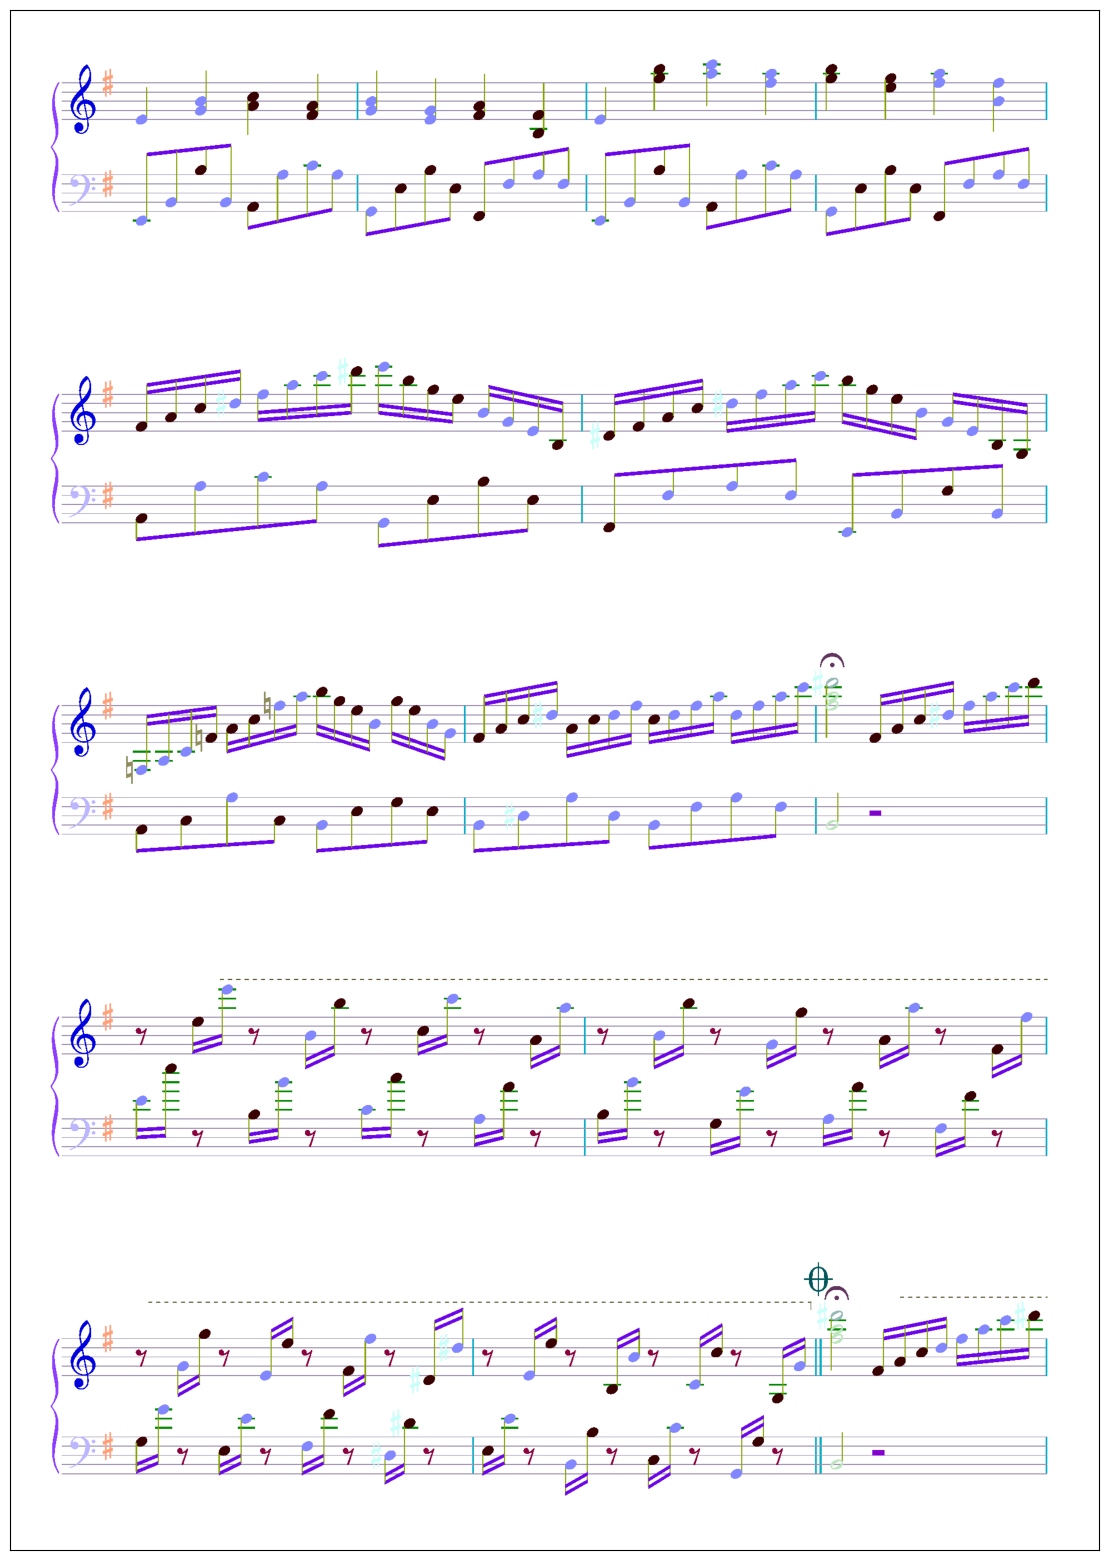

In [28]:
# 画像読み込み
ex_img_path = images_dir / filename
ex_seg_path = seg_dir / seg_filename
img_origin = Image.open(ex_seg_path).convert('RGB')
img_np = np.array(img_origin)
print(type(img_origin))
print(type(img_np))
show_img(img_np)

## 2. 小節線のピクセル位置を取得

In [29]:
def hex_to_rgb(hex_color):
    """ヘックスカラーコードをRGBに変換する関数"""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

In [30]:
def find_color_pixels(image_array: np.ndarray, hex_color: str) -> np.ndarray:
    """指定した色のピクセルの座標を取得する"""
    target_color_rgb = hex_to_rgb(hex_color)
    # 画像がRGBAの場合、RGBだけに変換する
    if image_array.shape[2] == 4:  # 4チャンネル(RGBA)の場合
        image_array = image_array[:, :, :3]  # RGBの3チャンネルに切り取る

    # ターゲットカラーと一致するピクセルを見つける
    target_pixels = np.all(image_array == target_color_rgb, axis=-1)

    # 一致するピクセルの座標を取得
    coordinates = np.argwhere(target_pixels)
    return coordinates

In [31]:
target_color_hex = "#00acc6" # 小節線の色
barline_pixcel_coordinates = find_color_pixels(img_np, target_color_hex)
print(barline_pixcel_coordinates)

# # 一致するピクセルの色を赤に変更（(255, 0, 0) = 赤色）
# img_res = img_np.copy()
# for coord in barline_pixcel_coordinates:
#     img_res[coord[0], coord[1]] = [255, 0, 0]  # 赤色に変更

# # numpy配列をPillowのImageオブジェクトに戻す
# modified_image = Image.fromarray(img_res)

# # 結果を表示
# modified_image.show()

[[ 131  624]
 [ 131  625]
 [ 131  626]
 ...
 [2633 1864]
 [2633 1865]
 [2633 1866]]


In [32]:
def group_coordinates_by_distance(all_coordinates, threshold_distance):
    """
    すべての座標に対して距離がしきい値以下であれば同じグループ（オブジェクト）とみなす。
    KDTreeを使用して、効率的に近傍探索を行いグループ化します。

    Args:
        all_coordinates (list of tuples): 座標情報 [(x1, y1), (x2, y2), ...]。
        threshold_distance (float): グループ化するための距離のしきい値。

    Returns:
        list of list of tuples: グループ化された座標のリスト。
    """
    # 座標をnumpy配列に変換
    coordinates = np.array(all_coordinates)

    # KDTreeを作成
    tree = KDTree(coordinates)

    # 各座標のグループ化結果を格納するためのリスト
    groups = []
    
    # まだ処理されていない座標を追跡するフラグ
    unprocessed = set(range(len(coordinates)))

    # 各座標に対して探索
    while unprocessed:
        # まだ処理されていない最初の座標を取得
        index = unprocessed.pop()
        
        # 新しいグループを作成
        group = [index]
        
        # 近傍探索用のキューを用意
        queue = [index]
        
        while queue:
            current_index = queue.pop()
            # 現在の座標からしきい値以内の近傍点を探索
            neighbors = tree.query_ball_point(coordinates[current_index], threshold_distance)
            
            # 未処理の近傍点のみを追加
            for neighbor in neighbors:
                if neighbor in unprocessed:
                    unprocessed.remove(neighbor)
                    queue.append(neighbor)
                    group.append(neighbor)
        
        # グループを保存
        groups.append([all_coordinates[i] for i in group])
    
    return groups

In [33]:
def draw_bounding_boxes(image, bounding_boxes):
    """
    バウンディングボックスを画像に描画します。

    Args:
        image (numpy array): OpenCVで読み込んだ画像。
        bounding_boxes (list of tuples): バウンディングボックス [(x, y, width, height), ...] のリスト。
    
    Returns:
        numpy array: バウンディングボックスが描画された画像。
    """
    image_ = image.copy()
    for box in bounding_boxes:
        x, y, width, height = box
        cv2.rectangle(image_, (y, x), (y + height, x + width), (255, 0, 0), 2)
    
    return image_

In [34]:
def calculate_bounding_boxes_from_groups(groups):
    """
    グループ化された座標リストから、バウンディングボックスを計算します。
    
    Args:
        groups (list of list of tuples): グループ化された座標のリスト。

    Returns:
        list of tuples: 各オブジェクトのバウンディングボックス [(x, y, width, height), ...] のリスト。
    """
    bounding_boxes = []
    for group in groups:
        x_coordinates = [coord[0] for coord in group]
        y_coordinates = [coord[1] for coord in group]
        x_min, x_max = min(x_coordinates), max(x_coordinates)
        y_min, y_max = min(y_coordinates), max(y_coordinates)
        width = x_max - x_min
        height = y_max - y_min
        bounding_boxes.append((x_min, y_min, width, height))
    
    return bounding_boxes

画像のサイズ：　 (2772, 1960, 3)


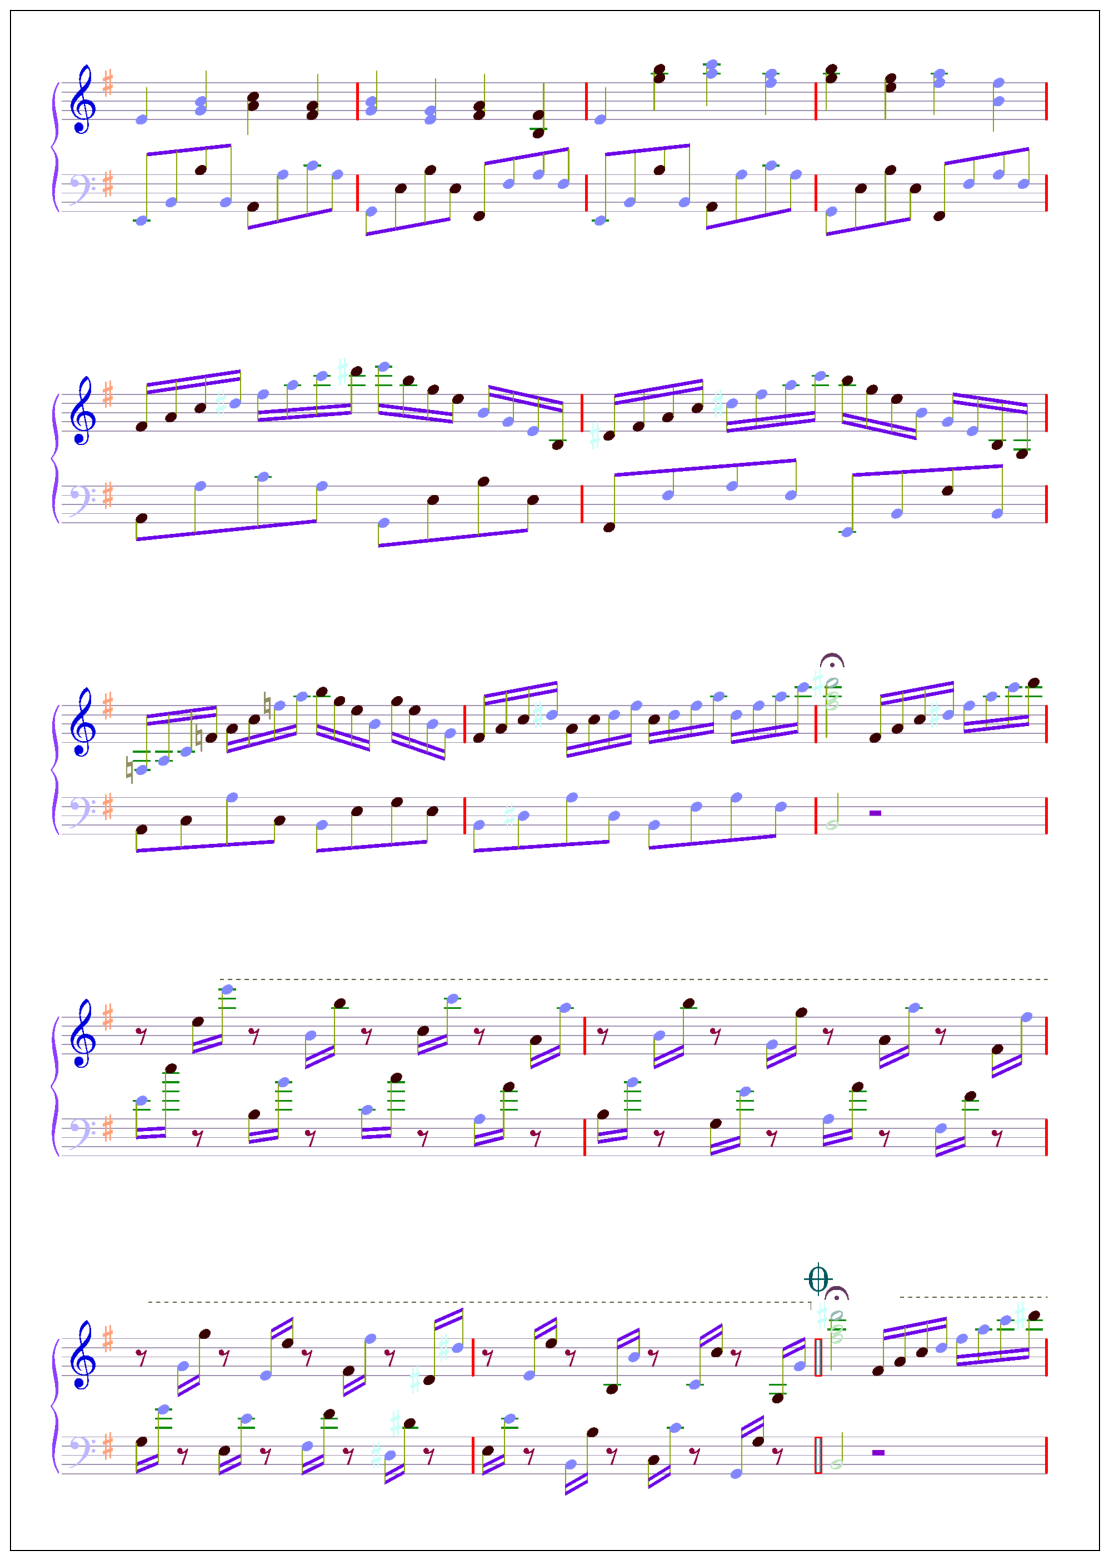

In [35]:
# しきい値距離 (この値はデータに応じて調整する)
threshold_distance = 20

# 距離に基づいて座標をグループ化
grouped_coordinates = group_coordinates_by_distance(barline_pixcel_coordinates, threshold_distance)

# グループ化された座標からバウンディングボックスを計算
bounding_boxes = calculate_bounding_boxes_from_groups(grouped_coordinates)

# バウンディングボックスを描画
image_with_boxes = draw_bounding_boxes(img_np, bounding_boxes)

# 画像を表示
show_img(image_with_boxes)


In [41]:
print(f"小節線の総ピクセル数：{len(barline_pixcel_coordinates)}")
print(f"小節線の検出数：{ len(bounding_boxes)}")

小節線の総ピクセル数：5891
小節線の検出数：28


In [39]:
bounding_boxes

[(np.int64(131), np.int64(624), np.int64(66), np.int64(2)),
 (np.int64(131), np.int64(1036), np.int64(66), np.int64(2)),
 (np.int64(131), np.int64(1449), np.int64(66), np.int64(2)),
 (np.int64(131), np.int64(1864), np.int64(66), np.int64(2)),
 (np.int64(297), np.int64(624), np.int64(64), np.int64(2)),
 (np.int64(297), np.int64(1036), np.int64(64), np.int64(2)),
 (np.int64(297), np.int64(1449), np.int64(64), np.int64(2)),
 (np.int64(297), np.int64(1864), np.int64(64), np.int64(2)),
 (np.int64(692), np.int64(1028), np.int64(66), np.int64(2)),
 (np.int64(692), np.int64(1864), np.int64(66), np.int64(2)),
 (np.int64(856), np.int64(1028), np.int64(66), np.int64(2)),
 (np.int64(856), np.int64(1864), np.int64(66), np.int64(2)),
 (np.int64(1252), np.int64(817), np.int64(66), np.int64(2)),
 (np.int64(1252), np.int64(1449), np.int64(66), np.int64(2)),
 (np.int64(1252), np.int64(1864), np.int64(66), np.int64(2)),
 (np.int64(1418), np.int64(817), np.int64(64), np.int64(2)),
 (np.int64(1418), np.int